# Hackathon #1 — Superstore Sales & Profitability Analysis: The Hidden Cost of Discounting

**Author:** Mattia Coletto (solo)

**Problem Statement:** Not all regions, states, or product categories that generate high sales are actually profitable. This analysis investigates whether excessive discounting is driving unprofitability across the US Superstore dataset, and identifies specifically where (which states, categories, and sub-categories) the problem is concentrated — in order to make an actionable recommendation.

**Data Source:**
- Primary dataset: Sample - Superstore (9,994 orders, 21 columns) — loaded directly from a GitHub-hosted CSV
- External data source: Live USD→EUR exchange rate via the Frankfurter API (api.frankfurter.dev), used to express Sales and Profit in EUR alongside the original USD figures

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import scipy.stats as stats
# import requests

## 2. Load Data

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/sumit0072/Superstore-Data-Analysis/main/Sample%20-%20Superstore.csv"
df = pd.read_csv(url, encoding="latin1")

print(df.shape)
df.head()

(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
import requests

response = requests.get("https://api.frankfurter.dev/v1/latest?base=USD&symbols=EUR")
rate = response.json()["rates"]["EUR"]
print(f"1 USD = {rate} EUR")

df["Sales_EUR"] = df["Sales"] * rate
df["Profit_EUR"] = df["Profit"] * rate

1 USD = 0.86678 EUR


## 3. Data Cleaning

In [4]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Sales_EUR        0
Profit_EUR       0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code        int64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
Sales_EUR        float64
Profit_EUR       float64
dtype: object

In [7]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df.dtypes

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Sales_EUR               float64
Profit_EUR              float64
dtype: object

## 4. Exploratory Data Analysis

Not all states that generate the most sales are actually the most profitable — some high-revenue states may be losing money due to discounting.

In [8]:
df[["Sales", "Profit", "Discount", "Quantity"]].describe()

,Sales,Profit,Discount,Quantity
count,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574
std,623.245101,234.260108,0.206452,2.225110
min,0.444000,-6599.978000,0.000000,1.000000
25%,17.280000,1.728750,0.000000,2.000000
50%,54.490000,8.666500,0.200000,3.000000
75%,209.940000,29.364000,0.200000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000


### Hypothesis
Not all states/regions that generate the most sales are the most profitable — heavy discounting may be causing some high-revenue segments to actually lose money.

In [9]:
region_summary = df.groupby("Region")[["Sales", "Profit", "Discount"]].mean()
region_summary["Total_Sales"] = df.groupby("Region")["Sales"].sum()
region_summary["Total_Profit"] = df.groupby("Region")["Profit"].sum()
region_summary

,Sales,Profit,Discount,Total_Sales,Total_Profit
Region,,,,,
Central,215.772661,17.092709,0.240353,501239.8908,39706.3625
East,238.336110,32.135808,0.145365,678781.2400,91522.7800
South,241.803645,28.857673,0.147253,391721.9050,46749.4303
West,226.493233,33.849032,0.109335,725457.8245,108418.4489


### Testing the hypothesis: Discount vs. Profit correlation

The Region-level breakdown above showed a pattern: regions with higher average discounts (like Central) had lower average profit, while regions with lower discounts (like West) had higher profit. But that's only 4 data points (one per region) — not strong evidence on its own.

To test this properly, we calculate the Pearson correlation coefficient between `Discount` and `Profit` across all 9,994 individual orders. This tells us:
- **Direction**: does profit tend to go down as discount goes up? (a negative correlation would confirm this)
- **Strength**: how strong is that relationship, on a scale from -1 (perfectly negative) to +1 (perfectly positive)

A strongly negative value here would confirm the hypothesis at the order level, not just the region-average level.

In [10]:
df[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


**Result:** Discount and Profit have a moderate negative correlation (r ≈ -0.22). This confirms the hypothesis directionally — higher discounts are associated with lower profit — but the relationship is moderate, not strong, meaning discount alone doesn't explain most of the variation in profit. Other factors (e.g. product category, order size) likely play a role too.

### Which states are actually losing money?

Region-level and correlation results point to a discount-driven profit problem, but "Region" is too coarse to act on. Breaking this down to the State level shows exactly where the losses are concentrated.

In [11]:
state_summary = df.groupby("State")[["Sales", "Profit"]].sum().sort_values("Profit")
state_summary.head(10)

,Sales,Profit
State,,
Texas,170188.0458,-25729.3563
Ohio,78258.1360,-16971.3766
Pennsylvania,116511.9140,-15559.9603
Illinois,80166.1010,-12607.8870
North Carolina,55603.1640,-7490.9122
Colorado,32108.1180,-6527.8579
Tennessee,30661.8730,-5341.6936
Arizona,35282.0010,-3427.9246
Florida,89473.7080,-3399.3017


### Are these losses actually discount-driven?

To confirm discounting is the mechanism behind these specific state losses (not something else, like shipping costs or returns), we check the average discount for these top loss-making states.

In [12]:
loss_states = state_summary.head(10).index
df[df["State"].isin(loss_states)].groupby("State")["Discount"].mean().sort_values(ascending=False)

State
Illinois          0.390041
Texas             0.370193
Pennsylvania      0.328620
Ohio              0.324947
Colorado          0.316484
Arizona           0.303571
Florida           0.299347
Tennessee         0.291257
Oregon            0.288710
North Carolina    0.283534
Name: Discount, dtype: float64

**Result:** The 10 least profitable states all carry average discounts of 28–39%, roughly double the dataset-wide average (15.6%). This confirms the hypothesis with much stronger, more specific evidence than the region-level view alone: excessive discounting — not lower sales volume — is the primary driver of unprofitability in these states. Texas, Ohio, and Pennsylvania are the most severe cases, each losing over $15K despite substantial sales volume.

### Which product categories are driving the discount problem?

Now that we know excessive discounting is hurting profit in specific states, the next actionable question is: which product categories/sub-categories are being discounted the most — and are they the same ones causing the losses? This tells us where to actually intervene (e.g. a discounting policy change), rather than just naming states.

In [13]:
category_summary = df.groupby("Category")[["Sales", "Profit", "Discount"]].mean()
category_summary["Total_Profit"] = df.groupby("Category")["Profit"].sum()
category_summary.sort_values("Total_Profit")

,Sales,Profit,Discount,Total_Profit
Category,,,,
Furniture,349.834887,8.699327,0.173923,18451.2728
Office Supplies,119.324101,20.327050,0.157285,122490.8008
Technology,452.709276,78.752002,0.132323,145454.9481


### Drilling into Sub-Category

Furniture stands out with the lowest average profit despite solid sales. But "Furniture" bundles several very different product types — breaking down to Sub-Category should reveal whether the whole category is weak, or just one or two specific products are dragging it down.

In [14]:
subcat_summary = df.groupby("Sub-Category")[["Sales", "Profit", "Discount"]].mean()
subcat_summary["Total_Profit"] = df.groupby("Sub-Category")["Profit"].sum()
subcat_summary.sort_values("Total_Profit")

,Sales,Profit,Discount,Total_Profit
Sub-Category,,,,
Tables,648.794771,-55.565771,0.261285,-17725.4811
Bookcases,503.859633,-15.230509,0.211140,-3472.5560
Supplies,245.650200,-6.258418,0.076842,-1189.0995
Fasteners,13.936774,4.375660,0.082028,949.5182
Machines,1645.553313,29.432669,0.306087,3384.7569
Labels,34.303055,15.236962,0.068681,5546.2540
Art,34.068834,8.200737,0.074874,6527.7870
Envelopes,64.867724,27.418019,0.080315,6964.1767
Furnishings,95.825668,13.645918,0.138349,13059.1436


### Refined finding: it's not discounting in general — it's Tables specifically

Only 3 of 17 sub-categories are net-unprofitable: Tables (-$17,725), Bookcases (-$3,473), and Supplies (-$1,189). Tables alone drives most of the Furniture category's weakness.

Importantly, high discounting does not universally cause losses — Binders (37.2% avg. discount, the highest in the dataset) is highly profitable (+$30,222), and Machines (30.6% discount) is also profitable. This means Tables' problem isn't discounting alone — it's the combination of an already-thin-margin product (large, costly-to-ship furniture) being discounted on top of that. This is a more precise, more actionable finding than "discounting hurts profit" in general: the real recommendation is to reduce or cap discounts specifically on Tables and Bookcases, not on Binders, Machines, or other high-discount-but-profitable products.

## 5. Visualizations

### Chart 1: Total Profit by State

The state-level table earlier showed 10 states with negative total profit, led by Texas, Ohio, and Pennsylvania. A bar chart makes the scale of these losses immediately visible compared to the profitable states — red bars mark the losses, blue bars mark profitable states.

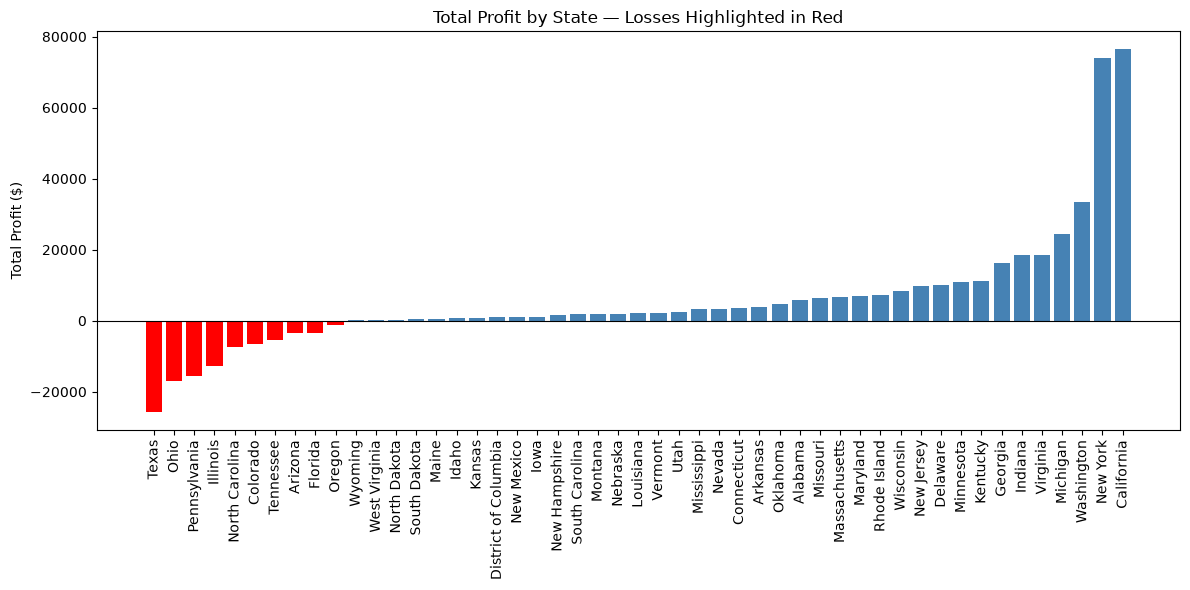

In [15]:
plt.figure(figsize=(12, 6))
state_profit = df.groupby("State")["Profit"].sum().sort_values()
colors = ["red" if x < 0 else "steelblue" for x in state_profit]
plt.bar(state_profit.index, state_profit.values, color=colors)
plt.xticks(rotation=90)
plt.ylabel("Total Profit ($)")
plt.title("Total Profit by State — Losses Highlighted in Red")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Chart 2: Discount vs. Profit (all orders)

The correlation coefficient (r ≈ -0.22) confirmed a moderate negative relationship between discount and profit, but a number alone doesn't show the shape of that relationship. This scatter plot shows every individual order, making it possible to see whether the pattern is a gradual decline, a sharp cutoff at a specific discount level, or something else — like a subset of orders with extreme losses at high discounts.

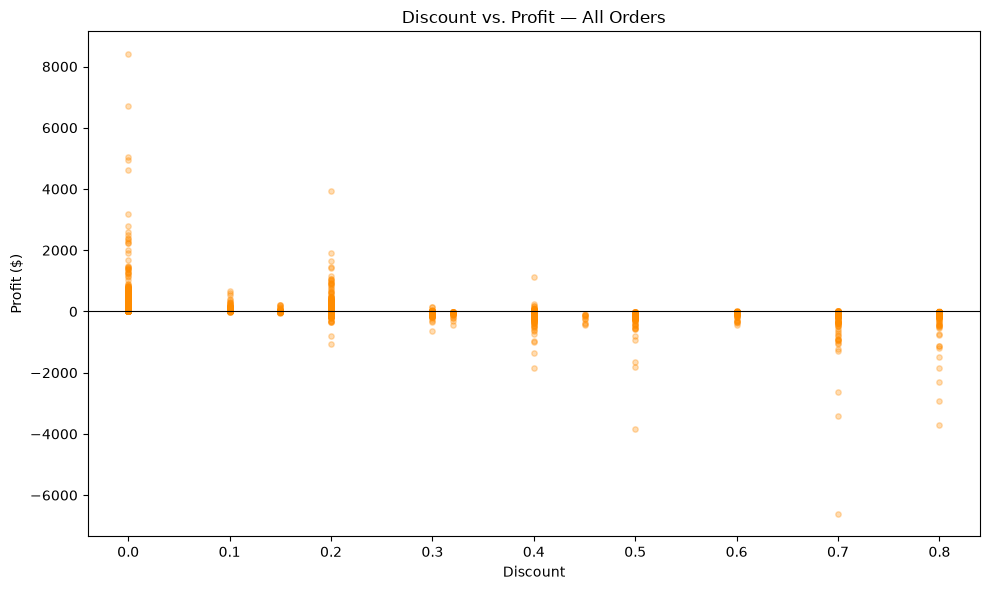

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Discount"], df["Profit"], alpha=0.3, s=15, color="darkorange")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.title("Discount vs. Profit — All Orders")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

**Observation:** The relationship isn't a smooth linear decline — discounts cluster at fixed values (Superstore applies discounts in set increments, not continuously), and the *severity* of losses grows sharply at 50%+ discount. Below ~30% discount, losses rarely exceed -$1,000 per order; above 50%, losses of -$3,000 to -$6,600 become visible. This suggests the real risk isn't moderate discounting, but specifically deep discounts (50%+) on individual orders.

### Chart 3: Total Profit by Sub-Category

The sub-category breakdown found only 3 of 17 sub-categories are unprofitable — Tables, Bookcases, and Supplies — with Tables far the worst. This chart makes that concentration visually obvious against the 14 profitable sub-categories.

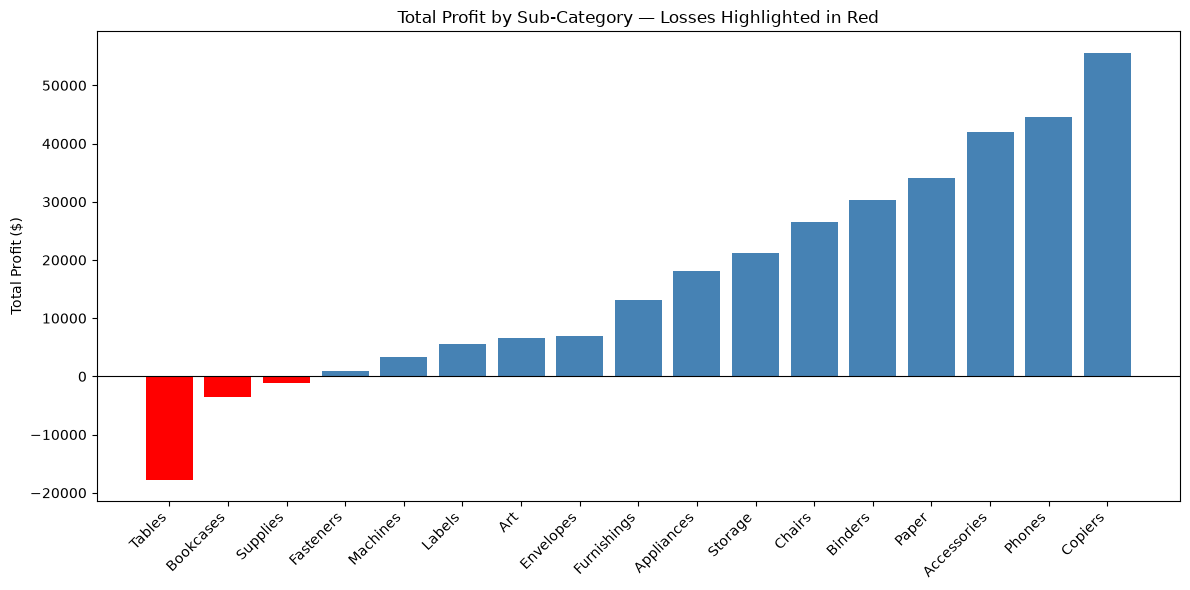

In [17]:
plt.figure(figsize=(12, 6))
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
colors = ["red" if x < 0 else "steelblue" for x in subcat_profit]
plt.bar(subcat_profit.index, subcat_profit.values, color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total Profit ($)")
plt.title("Total Profit by Sub-Category — Losses Highlighted in Red")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### Chart 4: Average Discount by Sub-Category

Pairing this against Chart 3 tests whether high discount reliably predicts loss. If the story were that simple, this chart would mirror Chart 3 in reverse. Instead, we already know Binders bucks the trend (highest discount, yet highly profitable) — this chart makes that exception visible alongside the real pattern in Tables and Bookcases.

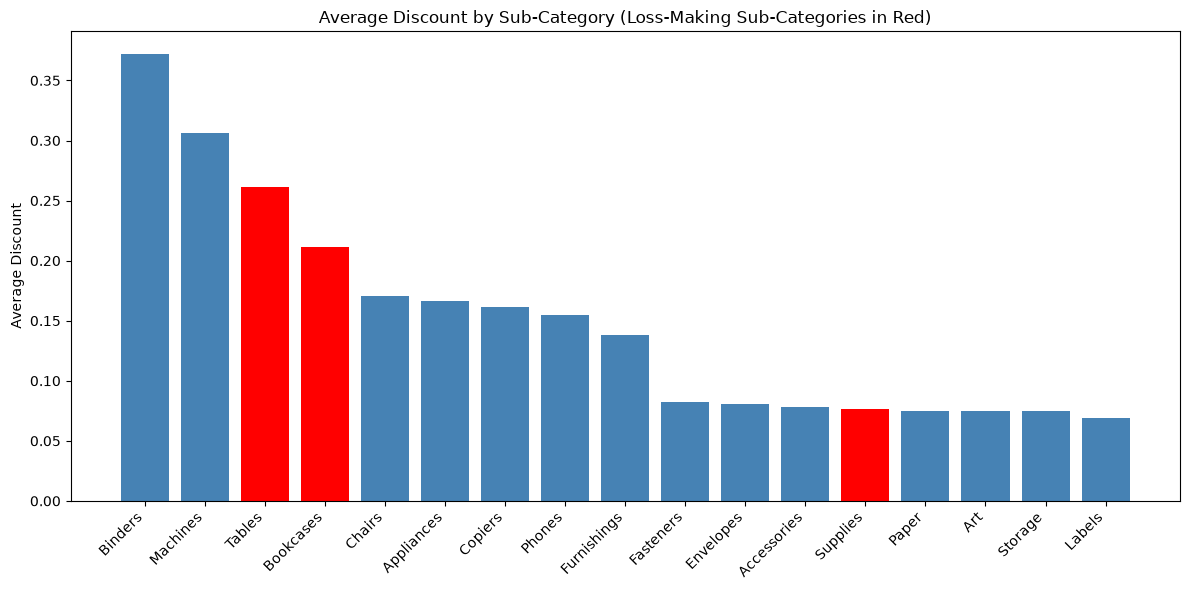

In [18]:
plt.figure(figsize=(12, 6))
subcat_discount = df.groupby("Sub-Category")["Discount"].mean().sort_values(ascending=False)
colors = ["red" if idx in ["Tables", "Bookcases", "Supplies"] else "steelblue" for idx in subcat_discount.index]
plt.bar(subcat_discount.index, subcat_discount.values, color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Discount")
plt.title("Average Discount by Sub-Category (Loss-Making Sub-Categories in Red)")
plt.tight_layout()
plt.show()

**Observation:** This chart disproves a simple "high discount → loss" story. Binders and Machines have the two highest average discounts in the dataset (37% and 31%) yet are both solidly profitable — discount level alone doesn't determine profitability. Meanwhile, Supplies is unprofitable despite a low average discount (7.7%), similar to profitable sub-categories like Paper and Storage — meaning something other than discount (likely low margins or high per-unit cost) explains its loss. Tables and Bookcases sit in the middle of the discount range, not at either extreme.

**Revised conclusion:** Discount is a contributing factor for Tables and Bookcases specifically, but not a universal predictor of loss across all sub-categories. The earlier correlation (r ≈ -0.22) reflects this — real, but moderate — relationship. A more accurate recommendation is to review margin structure and shipping/handling costs for Tables, Bookcases, and Supplies individually, rather than assuming discount reduction alone will fix profitability.

## 6. Advanced Analysis


### Profit by Sub-Category and Region (Pivot Table)

The earlier analysis looked at Sub-Category and Region separately. A pivot table combines both dimensions at once, revealing whether Tables/Bookcases are unprofitable everywhere, or concentrated in specific regions — a more precise, more actionable view.

In [19]:
pivot = df.pivot_table(values="Profit", index="Sub-Category", columns="Region", aggfunc="sum")
pivot.loc[["Tables", "Bookcases", "Supplies"]]

Region,Central,East,South,West
Sub-Category,,,,
Tables,-3559.6504,-11025.3801,-4623.0579,1482.6073
Bookcases,-1997.9043,-1167.6318,1339.4918,-1646.5117
Supplies,-661.8881,-1155.1352,1.8773,626.0465


**Result:** The loss is not uniform across regions. Tables loses money in Central, East, and South, but is profitable in West (+$1,483) — with East alone responsible for nearly two-thirds of Tables' total loss (-$11,025). Bookcases is profitable in South (+$1,339) despite losing overall. This suggests region-specific factors (e.g. shipping costs, local pricing/discount practices) compound the sub-category-level problem — East and Central are the consistent trouble spots across all three loss-making sub-categories, while South and West are often fine or profitable for the same products.

### Profit Trend Over Time

Using the datetime-converted Order Date, this checks whether profitability has been improving, declining, or stable year over year — useful context for whether the discounting problem is a recent trend or a persistent one.

In [20]:
df["Order Year"] = df["Order Date"].dt.year
yearly_profit = df.groupby("Order Year")["Profit"].sum()
yearly_profit

Order Year
2014    49543.9741
2015    61618.6037
2016    81795.1743
2017    93439.2696
Name: Profit, dtype: float64

**Result:** Total profit grew every year from 2014 to 2017 ($49.5K → $61.6K → $81.8K → $93.4K), nearly doubling over the period. This is important context: the discounting issue in Tables, Bookcases, and Supplies is a persistent, specific drag on an otherwise healthy and growing business — not a sign of overall decline. Fixing the identified sub-category/region issues represents realistic upside on top of already-positive momentum, rather than a rescue effort.

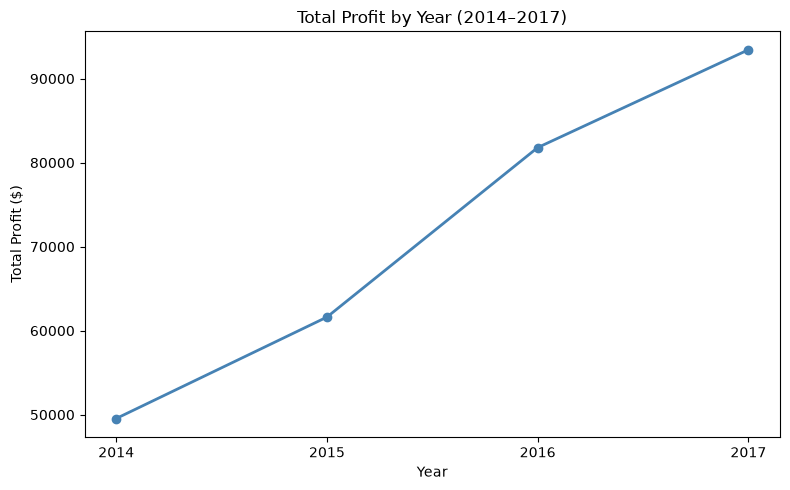

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(yearly_profit.index, yearly_profit.values, marker="o", linewidth=2, color="steelblue")
plt.xlabel("Year")
plt.ylabel("Total Profit ($)")
plt.title("Total Profit by Year (2014–2017)")
plt.xticks(yearly_profit.index)
plt.tight_layout()
plt.show()

### Statistical Test: Discounted vs. Non-Discounted Orders

To add statistical rigor beyond correlation, this runs an independent t-test comparing average profit between orders with no discount and orders with any discount applied — testing whether the difference is statistically significant, not just visually apparent.

In [22]:
from scipy import stats

no_discount = df[df["Discount"] == 0]["Profit"]
with_discount = df[df["Discount"] > 0]["Profit"]

t_stat, p_value = stats.ttest_ind(no_discount, with_discount)
print(f"No discount — mean profit: ${no_discount.mean():.2f}, n={len(no_discount)}")
print(f"With discount — mean profit: ${with_discount.mean():.2f}, n={len(with_discount)}")
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.6f}")

No discount — mean profit: $66.90, n=4798
With discount — mean profit: $-6.66, n=5196
t-statistic: 15.8786, p-value: 0.000000


**Result:** The difference is highly statistically significant (t = 15.88, p ≈ 0.000000). Orders with no discount average **+$66.90 profit**, while orders with any discount average **-$6.66** — meaning the average discounted order actually loses money. This confirms discounting has a real, statistically robust negative effect on profit overall, even though the effect isn't uniform at the sub-category level (e.g. Binders remains profitable despite high discounts). Both findings are compatible: discounting is a genuine risk on average, but its impact varies significantly by product type and region.

## 7. Insights & Conclusion

### Summary of Findings

1. **Discounting has a real, statistically significant negative effect on profit overall.** Orders with no discount average +$66.90 profit; orders with any discount average -$6.66 (t = 15.88, p ≈ 0.000000) — but the correlation is moderate (r ≈ -0.22), not absolute.

2. **The loss is concentrated, not widespread.** Only 10 of 49 states, and only 3 of 17 sub-categories (Tables, Bookcases, Supplies), are net unprofitable. Texas (-$25.7K), Ohio (-$17.0K), and Pennsylvania (-$15.6K) are the worst state-level offenders; Tables (-$17.7K) dwarfs the other two loss-making sub-categories combined.

3. **Discount level alone doesn't explain profitability.** Binders and Machines carry the two highest average discounts in the dataset (37% and 31%) yet remain solidly profitable, while Supplies loses money despite a low average discount (7.7%). The real driver for Tables and Bookcases appears to be a combination of already-thin margins (large, high-shipping-cost items) plus discounting on top — not discounting in isolation.

4. **The problem is also regional.** East and Central are the consistent trouble spots — East alone accounts for nearly two-thirds of Tables' total loss (-$11,025 of -$17,725) — while South and West are frequently profitable for the same products (e.g. Tables is profitable in West, Bookcases in South).

5. **The business overall is healthy and growing.** Total profit nearly doubled from 2014 ($49.5K) to 2017 ($93.4K). This is not a company in decline — it's a growing business with a specific, fixable inefficiency.

### Recommendation

Rather than a blanket discount reduction (which would risk profitable sub-categories like Binders and Machines), the data supports a **targeted intervention**:
- Cap or reduce discounts specifically on **Tables and Bookcases**, particularly in the **East and Central** regions, where losses are most concentrated
- Investigate **Supplies'** cost structure independently, since its loss isn't discount-driven
- Preserve current discounting practices on high-discount, high-profit sub-categories (Binders, Machines) — the data shows these can sustain deep discounts without harming profitability

This is a low-risk, high-precision fix: it targets roughly $22K of avoidable annual loss (Tables + Bookcases + Supplies combined) without disrupting the growth trajectory already in place.

### Limitations
- This analysis is correlational, not causal — we cannot confirm discounting *caused* these specific losses without controlling for other variables (e.g. shipping cost, order size, customer segment)
- The dataset spans 2014–2017; more recent data may show different patterns
